In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

# Load dataset
housing = fetch_california_housing()

# Create DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add target column
df["MedHouseVal"] = housing.target


# Display first 

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [9]:
# 3. Check missing values
print(df.isnull().sum())


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [2]:
# Features
X = df.drop("MedHouseVal", axis=1)

# Target
y = df["MedHouseVal"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


In [10]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


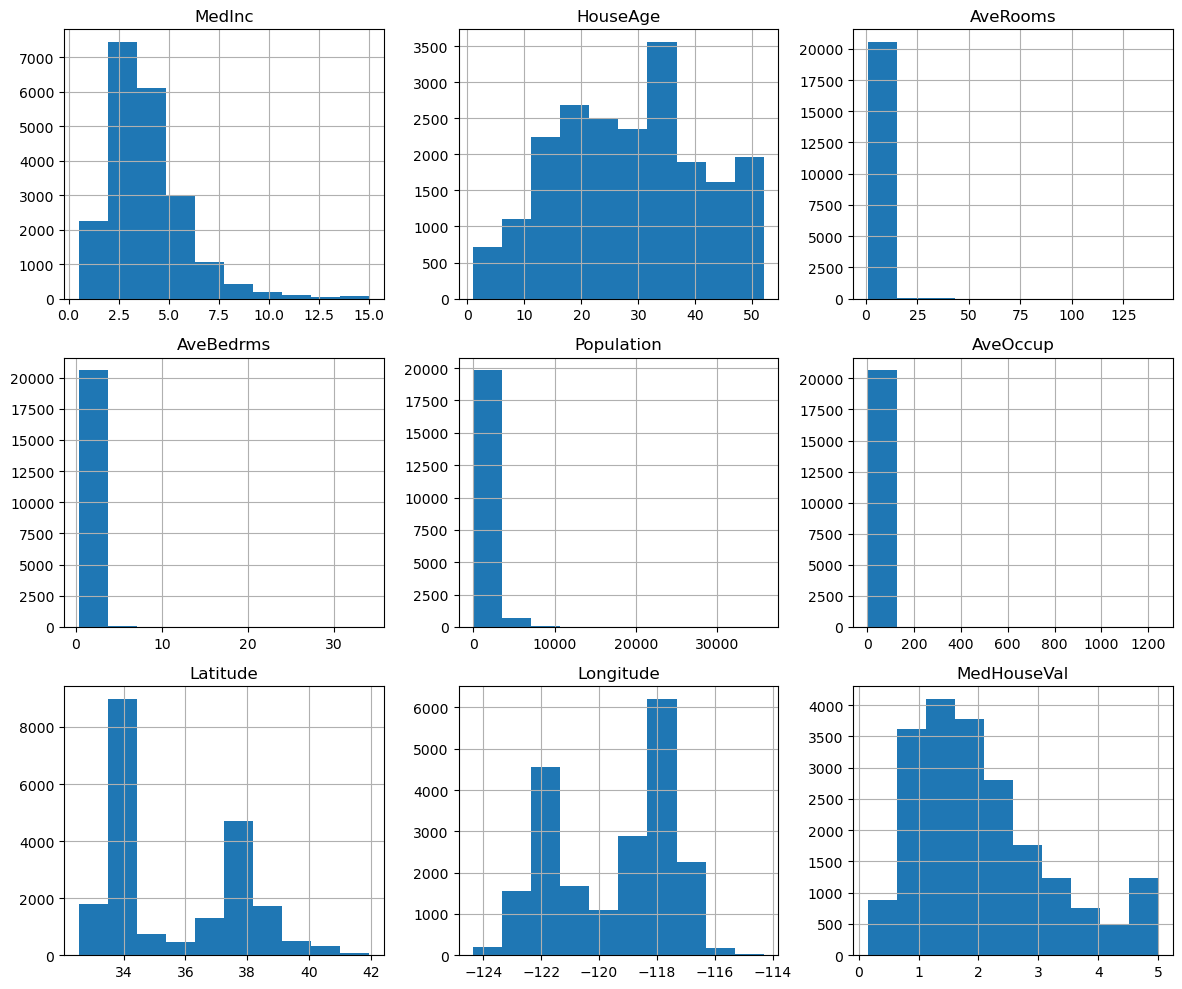

In [13]:
# 6. EDA - Distributions
import matplotlib.pyplot as plt
import seaborn as sns
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

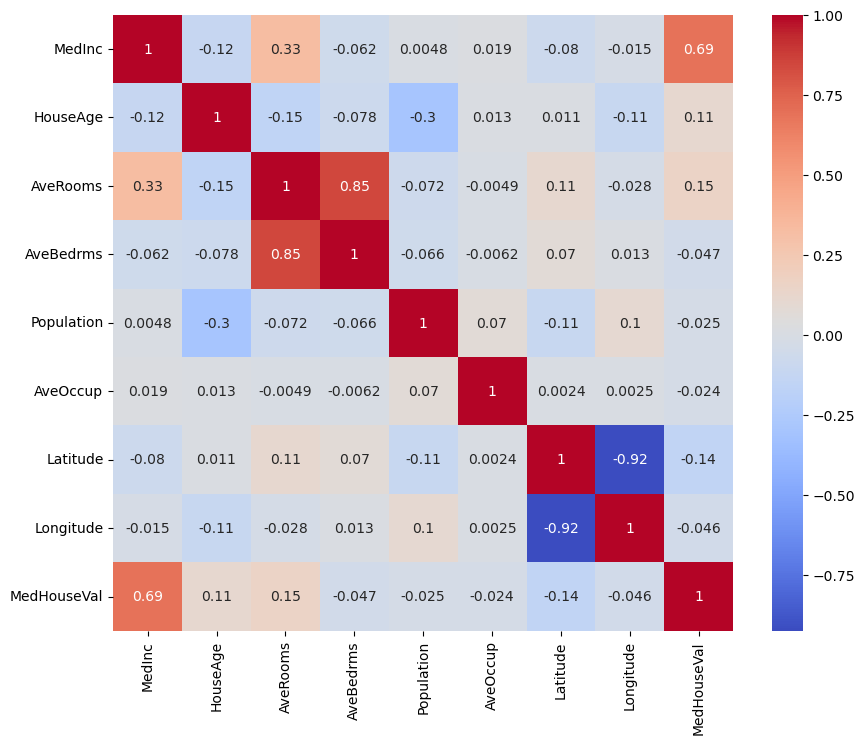

In [14]:
# 7. Correlation
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

Descriptive Statistics The descriptive statistics show that the dataset contains 20,640 observations with 8 input features and 1 target variable (MedHouseVal).

The features have different ranges and scales. For example, Population ranges from 3 to 35,682, while HouseAge ranges from 1 to 52. Some variables, such as AveRooms and AveOccup, show substantial differences between their mean and maximum values, indicating the presence of potential outliers.

The target variable, MedHouseVal, has a mean of approximately 2.07 and ranges from approximately 0.15 to 5.00.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16512, 8)
X_test: (4128, 8)
y_train: (16512,)
y_test: (4128,)


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Create models
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
gb = GradientBoostingRegressor(random_state=42)
svr = SVR()

# Train models
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

# SVR uses scaled data
svr.fit(X_train_scaled, y_train)

print("All models trained successfully!")

All models trained successfully!


In [6]:
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)

# SVR prediction using scaled test data
y_pred_svr = svr.predict(X_test_scaled)

print("Predictions generated successfully!")

Predictions generated successfully!


In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = {
    "Linear Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb,
    "SVR": y_pred_svr
}

results = []

for name, y_pred in models.items():
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mse, mae, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MSE", "MAE", "R2 Score"]
)

results_df

,Model,MSE,MAE,R2 Score
0,Linear Regression,0.555892,0.533200,0.575788
1,Decision Tree,0.495235,0.454679,0.622076
2,Random Forest,0.255368,0.327543,0.805123
3,Gradient Boosting,0.293997,0.371643,0.775645
4,SVR,0.357004,0.398599,0.727563


Model Evaluation

The models were evaluated using MSE, MAE, and R² Score.

Lower MSE indicates better performance.
Lower MAE indicates better performance.
Higher R² Score indicates better performance.
Best Performing Model

Random Forest Regressor performed best among the five models. It achieved the lowest MSE and MAE and the highest R² score of approximately 0.8051. This indicates that Random Forest was able to predict the median house value more accurately for this dataset.

Worst Performing Model

Linear Regression showed the lowest R² score of approximately 0.5758 and the highest MSE and MAE among the models. Therefore, it performed less effectively on this dataset compared with the other tested models.

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10, 20]
}
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 20, 'n_estimators': 100}
Best CV Score: 0.804601615150059


4. Cross-Validation & Hyperparameter Tuning

5-Fold Cross Validation was used to evaluate the Random Forest Regressor on different subsets of the training data.

GridSearchCV was used for hyperparameter tuning.

Hyperparameters Tuned
n_estimators: Number of trees in the Random Forest.
max_depth: Maximum depth of each decision tree.

The values tested were:

n_estimators: 50, 100
max_depth: None, 10, 20

The best parameters were selected based on the R² score.

Performance

Hyperparameter tuning helps to find the combination of parameters that gives better model performance. The tuned model was evaluated on the test data using MSE, MAE, and R² score.

Changing the hyperparameters can improve or reduce model performance. A suitable number of trees and tree depth can help the model learn the data better and reduce overfitting.

In [ ]:
5.

5. Selecting the Best Regression Model

Based on evaluation metrics, cross-validation, and hyperparameter tuning, Random Forest Regressor was selected as the best model.

MSE: 0.2554
MAE: 0.3275
R² Score: 0.8051
Best CV R² Score: 0.8046

The best hyperparameters were:

n_estimators = 100
max_depth = 20

Random Forest performed better than the other models because it combines multiple decision trees and can capture complex and non-linear relationships in the housing data. Using multiple trees also helps reduce prediction errors and overfitting compared with a single Decision Tree.

Therefore, Random Forest Regressor was selected as the final model for predicting median house prices.